<a href="https://colab.research.google.com/github/8009678200/ML.github.io/blob/main/iris_flower_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Iris Flower Classification

This notebook will guide you through the process of classifying iris flowers using a machine learning model. We will follow these steps:

1.  **Load the Dataset**: Load the Iris dataset, which is a classic dataset for classification tasks.
2.  **Exploratory Data Analysis (EDA)**: Understand the structure and characteristics of the dataset.
3.  **Data Preprocessing**: Prepare the data for training, if necessary (e.g., splitting into features and target).
4.  **Model Training**: Train a classification model on the preprocessed data.
5.  **Model Evaluation**: Evaluate the performance of the trained model.

### 1. Load the Dataset

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

# Load the Iris dataset
iris = load_iris()

# Create a DataFrame for better viewing
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['target_names'] = df['target'].map(lambda x: iris.target_names[x])

# Display the first 5 rows of the dataset
display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### 2. Exploratory Data Analysis (EDA)

In [ ]:
# Display basic information about the DataFrame
display(df.info())

# Display descriptive statistics of the DataFrame
display(df.describe())

# Check for missing values
display(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   target_names       150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


None

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0
target_names,0


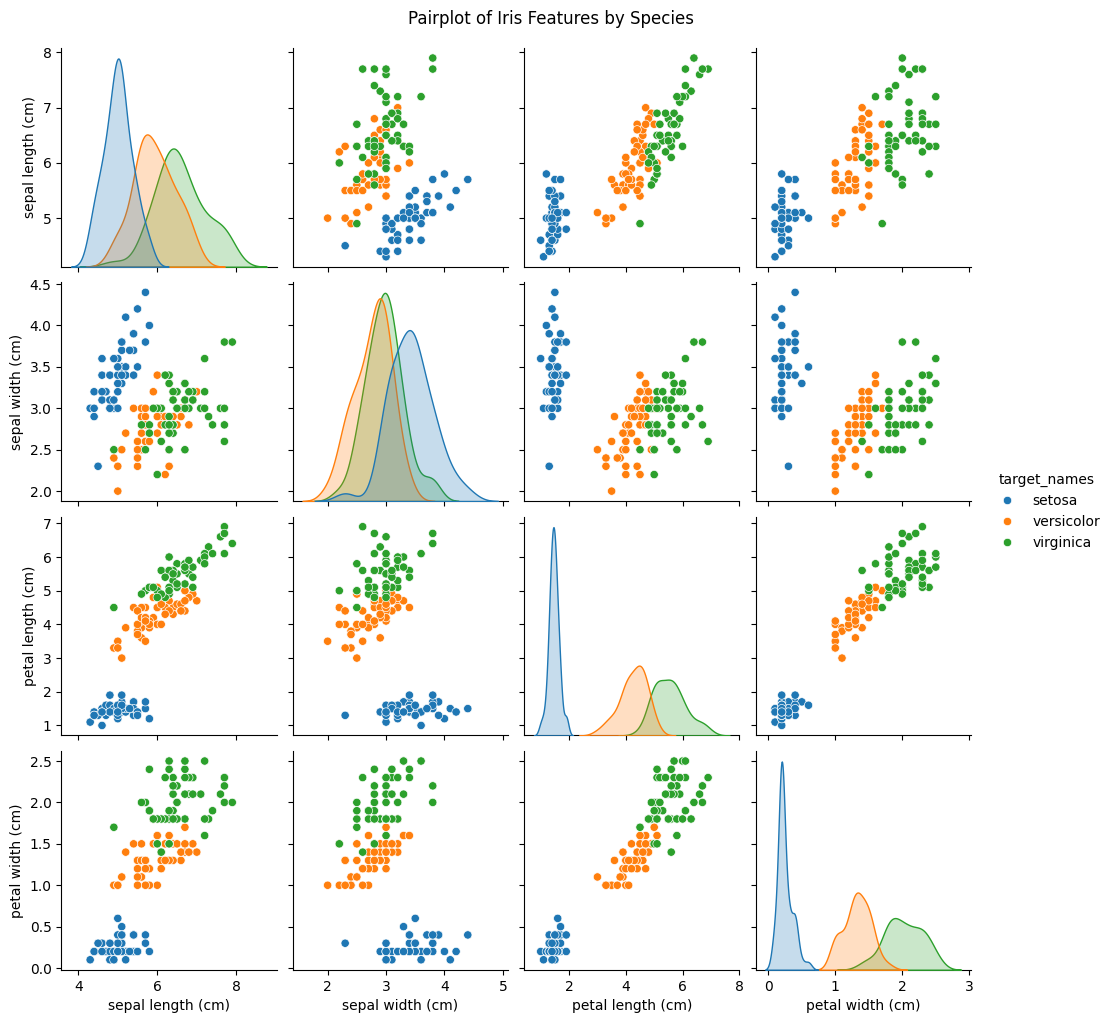

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pairplot to visualize the relationships between features
# and differentiate by target species
sns.pairplot(df, hue='target_names', vars=iris.feature_names)
plt.suptitle('Pairplot of Iris Features by Species', y=1.02) # Add a title above the plots
plt.show()

### 3. Data Preprocessing

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df[iris.feature_names]
y = df['target']

# Split the data into training and testing sets
# We'll use 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


### 4. Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
model = LogisticRegression(max_iter=200, random_state=42)

# Train the model using the training data
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


### 5. Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Display a classification report for more detailed metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Model Accuracy: 0.9667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### Confusion Matrix

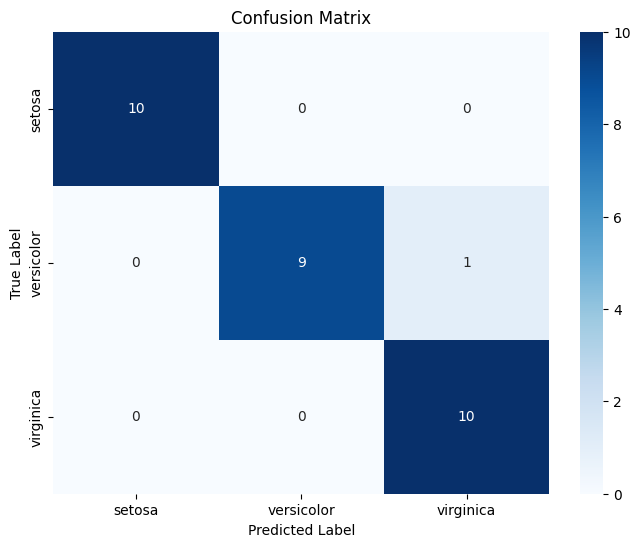

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

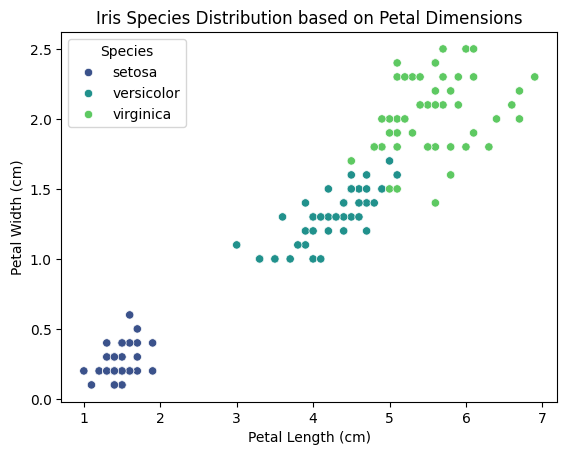

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for better color mapping and legend

# Create a scatter plot of petal length vs petal width, colored by target species
sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)', hue='target_names', palette='viridis')
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Iris Species Distribution based on Petal Dimensions")
plt.legend(title='Species')
plt.show()